This Notebook is related to <b>[Video 2](https://www.youtube.com/watch?v=Y7KCMaBDeDM)</b> & <b>[Video 3](https://www.youtube.com/watch?v=_Ke54TJqY9s)</b>. We will forecast the Random Walk and the process is:
1. Define if the data squence is stationary or not.
2. Run Transformation using <i>(First-ordering Differencing)</i>
3. Check the autocorrelation using ACF plot.
4. If the data is stationary & unauto-correlated then it's <b>Random Walk</b>


* The original dataset has various stocks data sequences, I chose `JNJ` stock because it has the largest data points among them all.

In [1]:
# Import initial libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

# Import time series libraries
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from scipy.stats.distributions import alpha

# Importing Model Evaluation Metrics
from sklearn.metrics import mean_squared_error

In [2]:
# Import the original dataset
df = pd.read_csv("https://raw.githubusercontent.com/RonySoliman/Time-Series-Forecasting/refs/heads/main/data/Part%202%3A%20Time%20Series%20Forecasting%3A%20The%20Random%20Walk/data.csv")

<b>
The original dataset has 10 unique stocks, but I will use only one stock (JNJ). Because each stock has its own distinct features. They are not equal in the amount of rows, JNJ is the biggest of them all. However it's worth mentioning that we analyze only the data of the last 4 years. Because <i>Random Walk</i> does not work well on a large dataset.
</b>

In [3]:
# Filter the original dataset, to create a subset with the stock JNJ
JNJ = df[df['Stock_Name'] == 'JNJ'].copy()
JNJ['Date'] = pd.to_datetime(JNJ['Date'])
JNJ['Year'] = JNJ['Date'].dt.year

# Aggregate yearly mean close
yearly_close = JNJ.groupby('Year')['Close'].mean()

In [4]:
# Defining the exact time durtion we will use
latest_date = pd.to_datetime(JNJ['Date']).max().date()
four_years_ago = latest_date - pd.DateOffset(years=4)
JNJ_last_four_years = JNJ[JNJ['Date'] >= four_years_ago].copy()

print(f"Data for the last four years (JNJ): {four_years_ago.strftime('%Y-%m-%d')} to {latest_date.strftime('%Y-%m-%d')}")
JNJ_last_four_years = JNJ_last_four_years.reset_index(drop=True)
display(JNJ_last_four_years.head())

Data for the last four years (JNJ): 2018-12-12 to 2022-12-12


,Date,Low,Open,Volume,High,Close,Adjusted Close,Stock_Name,Year
0,2018-12-12,147.000000,147.000000,8869200,148.490005,147.100006,132.378693,JNJ,2018
1,2018-12-13,146.800003,146.960007,6008300,148.589996,147.839996,133.044632,JNJ,2018
2,2018-12-14,130.199997,144.339996,58140200,145.380005,133.000000,119.689789,JNJ,2018
3,2018-12-17,126.830002,128.320007,36933100,131.649994,129.139999,116.216064,JNJ,2018
4,2018-12-18,129.199997,132.050003,24640100,132.800003,130.419998,117.367958,JNJ,2018


In [5]:
# Check the number of rows & columns of the subset
JNJ_last_four_years.shape

(1008, 9)

<b>
We can identify the rising trend in the next line graph, that tells us that the data is not stationary; and we need to apply a transformation method such as <i>First-ordering differencing</i> to ensure that the trend effect is minimized.
</b>

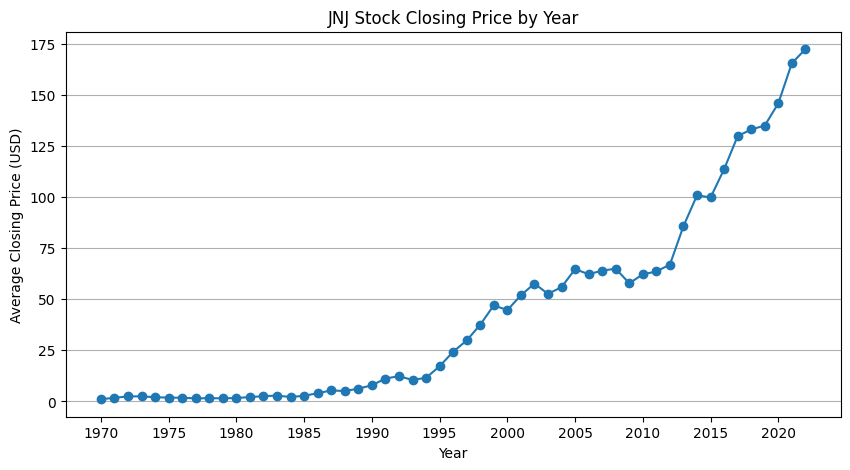

In [6]:
# Plot
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(yearly_close.index, yearly_close.values, marker='o')

# Set labels
ax.set_xlabel("Year")
ax.set_ylabel("Average Closing Price (USD)")
ax.set_title("JNJ Stock Closing Price by Year")

# Force x-axis to show ticks every 5 years
ax.xaxis.set_major_locator(MultipleLocator(5))

# To have these horizonal lines and plotting
plt.grid(axis='y')
plt.show();

# We can see the gradual trend between 1970 - 2020. We conclude that the data is not stationary.

In [7]:
# Applying the first-ordering differencing technique
diff_random_walk = np.diff(JNJ_last_four_years['Close'], n=1)
diff_random_walk

# As you can see that the first-ordering differencing generate an array.

array([  0.73999023, -14.83999634,  -3.86000061, ...,   0.02999878,
        -1.45999146,   0.43998718])

<b>
In the next cell, we can see the following results:

Since the ADF Statistic is negative number a little far from zero & the p-value is drastically diminutive. We can confirm that the data transformation is accurate and the data is now stationary.
</b>

In [8]:
# Check the ADF test
ADF_result = adfuller(diff_random_walk)
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

# We can conclude that the ADF Statistic value is largely negative & the p-value is significant.
# So we confirmly can say that the raw time series data is now stationary.

ADF Statistic: -10.427036805305551
p-value: 1.6474543829920142e-18


<b>
The resulting in the next ACF plot. You can notice that there are significant
coefficients up until lag 2. Then they abruptly become non-significant, as they remain in the shaded area of the plot. This means that we have a stationary moving average process of order 2. We can use a second-order moving average model, or MA(2) model, to forecast our stationary time series.
</b>

<Figure size 1000x800 with 0 Axes>

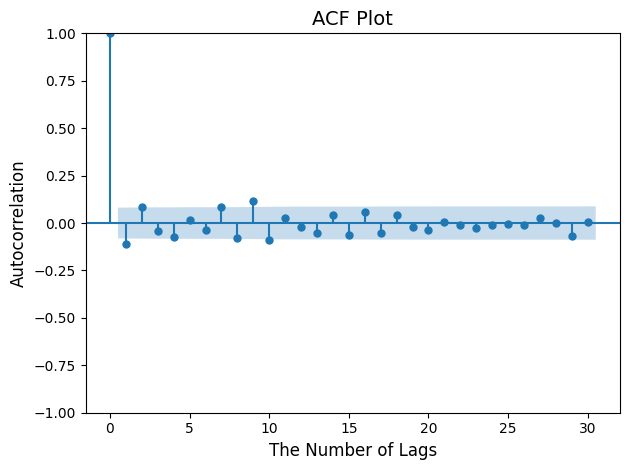

In [9]:
# Plot ACF
plt.figure(figsize=(10,8))
plot_acf(diff_random_walk, lags=30, alpha = 0.01)
plt.title('ACF Plot', fontsize=14)
plt.xlabel('The Number of Lags', fontsize=12)
plt.ylabel('Autocorrelation', fontsize=12)

plt.tight_layout()
plt.show();

#### **Section Two**: Forecasting A Random Walk

We use <i>Naive Forecasting Methods</i>:

a. **The Historical Mean**: forecasts all future values as the average of the historical series

b. **The Last Known Value** (Random Walk / Naïve): forecasts using the most recent observation

c. **The Drift Method**: extends a constant trend from the first to the last observed value

These three naive models serve as baselines against which proper **Tabular Machine Learning Models** must demonstrate improvement. You can think of them as the practical null hypothesis: if a model cannot consistently outperform these simple methods, its complexity is unjustified; meaning **a strong sign of overfitting** or failure to capture the underlying data-generating process.

**Tabular ML Models** (such as: Random Forest, XGBoost) treat each row independently & do not inherently respect sequence order or cyclical patterns unless the data is explicitly engineered.

*For example*, last month's sales are typically more predictive than sales from early last year. Similarly, cyclical proximity (December 31 being adjacent to January 1) is lost unless encoded via features like sine/cosine transformations.

Therefore, baseline selection must align with business requirements; including forecast horizon, relevant accuracy metrics, & the cyclical nature of the data. To ensure that even the most sophisticated **Tabular ML Models** are evaluated fairly against benchmarks that reflect real-world forecasting needs.

In [10]:
# This new subset extract the "Close" variable from our original JNJ dataset to forecast the Random Walk accurately
data = pd.DataFrame({'value':JNJ_last_four_years.Close})
print("The Shape of the JNJ[Close] subset is: ",data.shape)

The Shape of the JNJ[Close] subset is:  (1008, 1)


In [11]:
# Defining the training & testing subsets
train = data[:800]
test = data[800:]

print(train.shape, test.shape)

(800, 1) (208, 1)


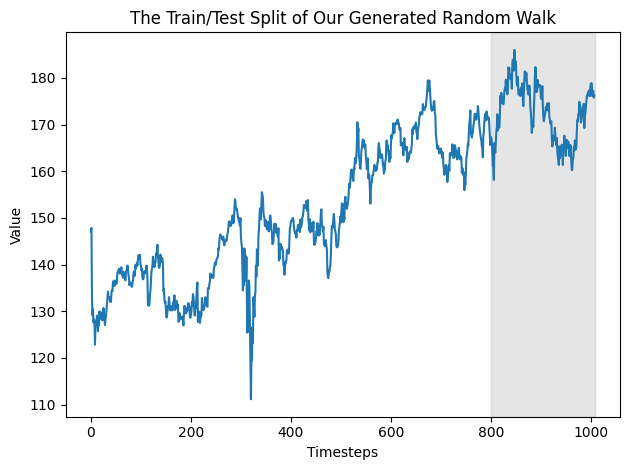

In [12]:
# The plot shows the flow of the data sequence, the grey vertical area represents the testing subset
fig, ax = plt.subplots()

ax.plot(JNJ_last_four_years.Close)
ax.set_title('The Train/Test Split of Our Generated Random Walk')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.axvspan(800, 1008, color='#808080', alpha=0.2)

plt.tight_layout()
plt.show();

In [13]:
# The 1st Naive Forcasting Method (The Average)
mean = np.mean(train['value'])
test.loc[:, 'pred_mean'] = mean
test.head();

/tmp/ipykernel_742/2245013106.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_mean'] = mean


In [14]:
# The 2nd Naive Forecasting Method (The Last Value)

last_value = train.iloc[-1].value
test.loc[:, 'pred_last'] = last_value
test.head();

/tmp/ipykernel_742/390557599.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_last'] = last_value


In [15]:
# The 3rd Naive Forecasting Method (The Drift)
deltaX = 800 - 1
deltaY = last_value - 0

# calculate the (drift)
drift = deltaY / deltaX
print(round(drift,6));

0.207259


In [16]:
# We concat the results of the three methods and attach them back to the subset we created out of JNJ[Close]
x_vals = np.arange(800, 1008, 1)

pred_drift = drift * x_vals

test.loc[:, 'pred_drift'] = pred_drift
test.head();

/tmp/ipykernel_742/1642964397.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_drift'] = pred_drift


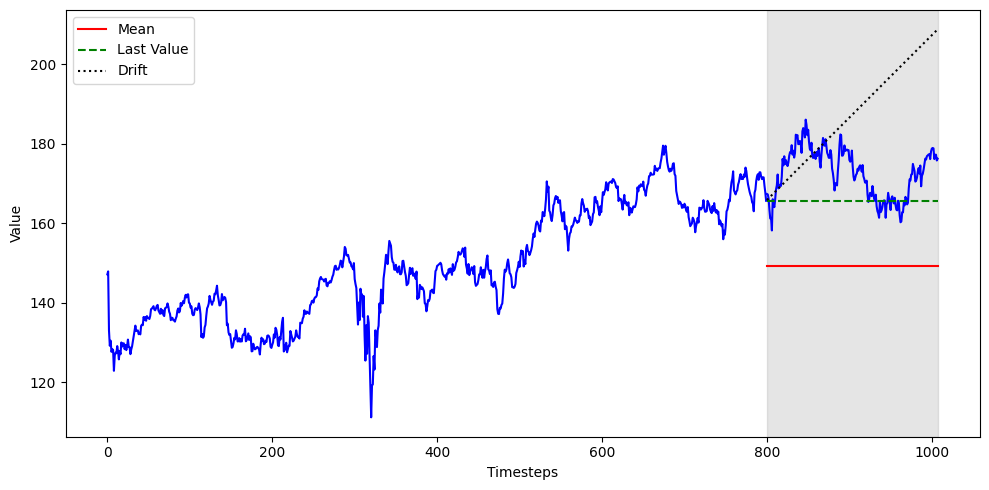

In [17]:
# Visualize the three methods with the Close unique data sequence
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(train.value, 'b-')
ax.plot(test.value, 'b-')
ax.plot(test.pred_mean, 'r-', label = 'Mean')
ax.plot(test.pred_last, 'g--', label = 'Last Value')
ax.plot(test.pred_drift, 'k:', label = 'Drift')

ax.axvspan(800, 1008, color='#808080', alpha = 0.2)
ax.legend(loc=2)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()
plt.show();

# As you can see that the three methods rn are failing to capture the unpredictable testing data points, we need to modify our approach.

#### Applying the Mean Squared Error (MSE)


In [18]:
# Run MSE on the 3 Naive Methods & then print the results
mse_mean = mean_squared_error(test.value, test.pred_mean)
mse_last = mean_squared_error(test.value, test.pred_last)
mse_drift = mean_squared_error(test.value, test.pred_drift)

print(f"Mean MSE: {round(mse_mean, 2)}")
print(f"Last Value MSE: {round(mse_last, 2)}")
print(f"Drift MSE: {round(mse_drift, 2)}");

Mean MSE: 584.51
Last Value MSE: 87.0
Drift MSE: 446.55


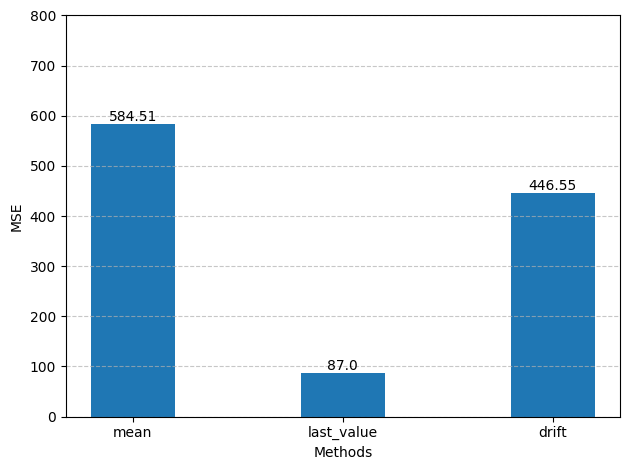

In [19]:
# Visualize the MSE results
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'drift']
y = [mse_mean, mse_last, mse_drift]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 800)

for index, value in enumerate(y):
    plt.text(x=index, y=value+5, s=str(round(value, 2)), ha='center')

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show();

# As you can see that the (Last Value) method outperform the other two methods.

**Conclusion:**

We can conclude that the Last Value is the best Naive Forecasting Method that give the closer result of the Random Walk.